In [1]:
import numpy
print(numpy.__version__)

1.26.4


In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
Built with CUDA: True
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Data Loading into dataframe

In [3]:
import pandas as pd

## Loading dataframes

In [4]:
df1 = pd.read_csv("Datasets/YouTube/youtube_comments_cleaned.csv")
df2 = pd.read_csv("Datasets/YouTube/YoutubeCommentsDataSet.csv")
df3 = pd.read_csv("Datasets/Twitter/Twitter_Data.csv")

column_names = ["Sentiment", "ids", "date", "flag", "user", "Text"]
df4 = pd.read_csv(
    r"Datasets/Twitter/training.1600000.processed.noemoticon.csv", 
    encoding='latin-1', 
    names=column_names
)

df5 = pd.read_csv("Datasets/Reddit/Reddit_Data.csv")
df6 = pd.read_csv("Datasets/Reddit/comments.csv")

## Processing df1

In [5]:
#Listing column names
print(df1.columns)

Index(['CommentID', 'VideoID', 'VideoTitle', 'AuthorName', 'AuthorChannelID',
       'CommentText', 'Sentiment', 'Likes', 'Replies', 'PublishedAt',
       'CountryCode', 'CategoryID'],
      dtype='object')


In [6]:
#Selecting the columns
df1 = df1[['CommentText', 'Sentiment']]
df1 = df1.rename(columns={'CommentText':'Text'})

In [7]:
print(df1['Sentiment'].unique())

['Neutral' 'Positive' 'Negative']


In [8]:
df1['Sentiment'] = df1['Sentiment'].str.lower()

In [9]:
print(df1['Sentiment'].unique())

['neutral' 'positive' 'negative']


In [10]:
#Taking View
print(df1.head())

                                                Text Sentiment
0                    Anyone know what movie this is?   neutral
1  The fact they're holding each other back while...  positive
2                        waiting next video will be?   neutral
3  Thanks for the great video.\n\nI don't underst...   neutral
4  Good person helping good people.\nThis is how ...  positive


In [11]:
#Length of the rows
print(len(df1))

1032225


## Processing df2

In [12]:
#Listing column names
print(df2.columns)

Index(['Comment', 'Sentiment'], dtype='object')


In [13]:
#printing no. of rows
print(len(df2))

18408


In [14]:
#Renaming the columns
df2 = df2.rename(columns={'Comment':'Text'})

In [15]:
print(df2.columns)

Index(['Text', 'Sentiment'], dtype='object')


In [16]:
print(df2.head())

                                                Text Sentiment
0  lets not forget that apple pay in 2014 require...   neutral
1  here in nz 50 of retailers don’t even have con...  negative
2  i will forever acknowledge this channel with t...  positive
3  whenever i go to a place that doesn’t take app...  negative
4  apple pay is so convenient secure and easy to ...  positive


## Processing df3

In [17]:
#printing columns
print(df3.columns)

Index(['clean_text', 'category'], dtype='object')


In [18]:
#renaming the columns
df3 = df3.rename(columns={'clean_text':'Text','category':'Sentiment'})

In [19]:
print(df3.columns)

Index(['Text', 'Sentiment'], dtype='object')


In [20]:
df3['Sentiment'] = df3['Sentiment'].replace({-1: 'negative', 0: 'neutral', 1: 'positive'})

In [21]:
print(df3.head())

                                                Text Sentiment
0  when modi promised “minimum government maximum...  negative
1  talk all the nonsense and continue all the dra...   neutral
2  what did just say vote for modi  welcome bjp t...  positive
3  asking his supporters prefix chowkidar their n...  positive
4  answer who among these the most powerful world...  positive


In [22]:
print(df3['Sentiment'].unique())

['negative' 'neutral' 'positive' nan]


In [23]:
print(len(df3))

162980


## Processing df4

In [24]:
#listing data
print(df4.head())

   Sentiment         ids                          date      flag  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               Text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [25]:
#Selecting columns
df4 = df4[['Text','Sentiment']]

In [26]:
print(df4.head())

                                                Text  Sentiment
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...          0
1  is upset that he can't update his Facebook by ...          0
2  @Kenichan I dived many times for the ball. Man...          0
3    my whole body feels itchy and like its on fire           0
4  @nationwideclass no, it's not behaving at all....          0


In [27]:
print(df4['Sentiment'].unique())

[0 4]


In [28]:
df4['Sentiment'] = df4['Sentiment'].replace({0: 'negative', 4: 'positive'})

In [29]:
print(df4.head())

                                                Text Sentiment
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  negative
1  is upset that he can't update his Facebook by ...  negative
2  @Kenichan I dived many times for the ball. Man...  negative
3    my whole body feels itchy and like its on fire   negative
4  @nationwideclass no, it's not behaving at all....  negative


In [30]:
print(len(df4))

1600000


## Processing df5

In [31]:
print(df5.head())

                                       clean_comment  category
0   family mormon have never tried explain them t...         1
1  buddhism has very much lot compatible with chr...         1
2  seriously don say thing first all they won get...        -1
3  what you have learned yours and only yours wha...         0
4  for your own benefit you may want read living ...         1


In [32]:
df5 = df5.rename(columns={'clean_comment':'Text','category':'Sentiment'})

In [33]:
print(df5.columns)

Index(['Text', 'Sentiment'], dtype='object')


In [34]:
df5['Sentiment'] = df5['Sentiment'].replace({-1: 'negative', 0: 'neutral', 1: 'positive'})

In [35]:
print(df5.head())

                                                Text Sentiment
0   family mormon have never tried explain them t...  positive
1  buddhism has very much lot compatible with chr...  positive
2  seriously don say thing first all they won get...  negative
3  what you have learned yours and only yours wha...   neutral
4  for your own benefit you may want read living ...  positive


In [36]:
print(len(df5))

37249


## Processing df6

In [37]:
print(df6.head())

   Post_ID                                         Post_Title Comment_ID  \
0  1l3e2dt  Video games are addictive by design and partic...    mw03xn7   
1  1l3e2dt  Video games are addictive by design and partic...    mw046xq   
2  1l3e2dt  Video games are addictive by design and partic...    mw04of4   
3  1l3e2dt  Video games are addictive by design and partic...    mw04qz8   
4  1l3e2dt  Video games are addictive by design and partic...    mw04rp1   

  Parent_ID                                               Body  \
0       NaN  Please remember what subreddit you are in, thi...   
1       NaN  > video games are predatory and designed to su...   
2       NaN  you're painting with an extremely broad brush,...   
3       NaN     lol...don't enjoy something. Get back to work!   
4       NaN  Video games being more addictive than other so...   

                 Author  Score  Level Sentiment  Confidence  Sentiment_Score  
0         AutoModerator      1      0  NEGATIVE    0.995359        

In [38]:
print(df6.columns)

Index(['Post_ID', 'Post_Title', 'Comment_ID', 'Parent_ID', 'Body', 'Author',
       'Score', 'Level', 'Sentiment', 'Confidence', 'Sentiment_Score'],
      dtype='object')


In [39]:
df6 = df6[['Body','Sentiment']]

In [40]:
df6 = df6.rename(columns={'Body':'Text'})

In [41]:
print(df6.columns)

Index(['Text', 'Sentiment'], dtype='object')


In [42]:
print(df6['Sentiment'].unique())

['NEGATIVE' 'POSITIVE']


In [43]:
df6['Sentiment'] = df6['Sentiment'].str.lower()

In [44]:
print(df6.head())

                                                Text Sentiment
0  Please remember what subreddit you are in, thi...  negative
1  > video games are predatory and designed to su...  negative
2  you're painting with an extremely broad brush,...  negative
3     lol...don't enjoy something. Get back to work!  negative
4  Video games being more addictive than other so...  negative


In [45]:
print(len(df6))

8108


## Concatinating all df's

In [46]:
df_master = pd.concat([df1,df2,df3,df4,df5,df6],ignore_index=True)

In [47]:
print(df_master.head())

                                                Text Sentiment
0                    Anyone know what movie this is?   neutral
1  The fact they're holding each other back while...  positive
2                        waiting next video will be?   neutral
3  Thanks for the great video.\n\nI don't underst...   neutral
4  Good person helping good people.\nThis is how ...  positive


In [48]:
print(len(df_master))

2858970


In [49]:
print(df_master['Sentiment'].unique())

['neutral' 'positive' 'negative' nan]


In [50]:
#Viewing random rows
print(df_master.sample(n=5))

                                                      Text Sentiment
798352             AoA! Sir can I contact you on WhatsApp.   neutral
1954528                        Happy birthday to me! haha   negative
1283771  @dorayoung i just thought the same thing  got ...  negative
1695886  At the Picturehouse for a Cambridge Film Trust...  negative
848874       The dolphin cry hits different in this one 😭🐬  negative


In [51]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2858970 entries, 0 to 2858969
Data columns (total 2 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   Text       object
 1   Sentiment  object
dtypes: object(2)
memory usage: 43.6+ MB


In [52]:
print("Sentiments Count values")
print(df_master['Sentiment'].value_counts())

Sentiments Count values
Sentiment
positive    1245571
negative    1197566
neutral      415826
Name: count, dtype: int64


In [53]:
# droping null value rows
df_master.dropna(subset=["Text","Sentiment"],inplace=True)

In [54]:
print(df_master.sample(n=5))

                                                      Text Sentiment
106120   i just installed visualnode 2019 with javascri...   neutral
1733868  Nylon string broken again  Off to take it back...  negative
1420232   @chi_yeah  hope your gonna be ok!!!! xxxxxxxxxxx  negative
2490014  Yay for catching up with roommates after their...  positive
2615981  Getting ready to go skydiving. How exciting to...  positive


In [55]:
print(len(df_master))

2858815


In [56]:
print(df_master['Sentiment'].unique())

['neutral' 'positive' 'negative']


In [57]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2858815 entries, 0 to 2858969
Data columns (total 2 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   Text       object
 1   Sentiment  object
dtypes: object(2)
memory usage: 65.4+ MB


In [58]:
print("Sentiments Count values")
print(df_master['Sentiment'].value_counts())

Sentiments Count values
Sentiment
positive    1245540
negative    1197564
neutral      415711
Name: count, dtype: int64


In [59]:
len(df_master)

2858815

# Visualizing the dataset

In [60]:
# !pip install matplotlib
import matplotlib.pyplot as plt


Bar chart saved as 'sentiment_distribution.png'


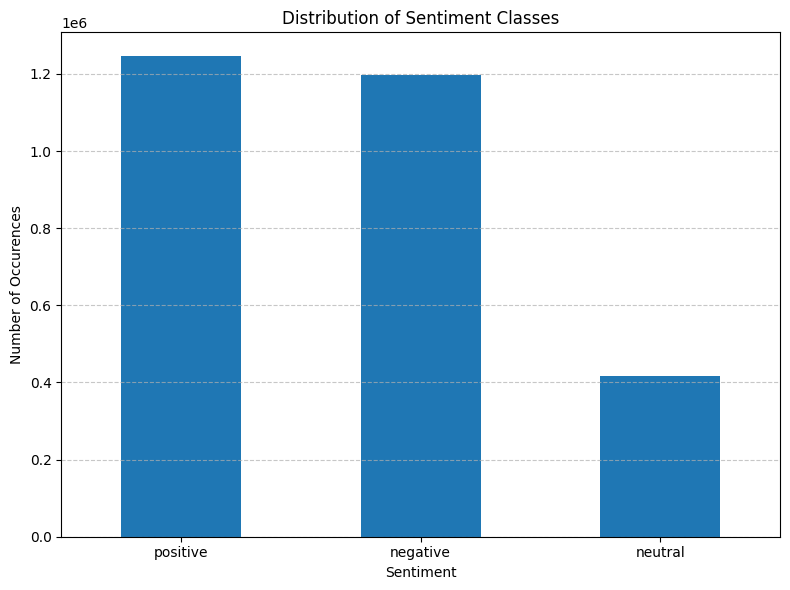

In [61]:
sentiment_counts = df_master['Sentiment'].value_counts()
plt.figure(figsize=(8,6))
sentiment_counts.plot(kind='bar')
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment')
plt.ylabel('Number of Occurences')
plt.xticks(rotation=0) #keep labels like positive upright
plt.grid(axis='y', linestyle='--', alpha=0.7) #Adds a helpful gird
plt.tight_layout() #Adjust plot to prevent labels from overlapping
plt.savefig("sentiment_distribution.png")
print("\nBar chart saved as 'sentiment_distribution.png'")

# Cleaning Text

## NLTK Downloads

In [62]:
'''
!pip install nltk
!pip install re
'''
import nltk
from nltk.corpus import stopwords
import re

In [63]:
nltk.download('stopwords')
print('NLTK stopwords downloaded.')

NLTK stopwords downloaded.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Predator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [64]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [65]:
keep_words = [
    'no','nor','not',
    'don',"don't",'didn',"didn't",'isn',"isn't",'aren',"aren't",
    'wasn',"wasn't",'weren',"weren't",'haven',"haven't",
    'hasn',"hasn't",'hadn',"hadn't",'won',"won't",
    'wouldn',"wouldn't",'shouldn',"shouldn't",
    'couldn',"couldn't",'mightn',"mightn't",
    'mustn',"mustn't",'needn',"needn't",'shan',"shan't",
    'but','against',
    'very','too','more','most',
    'should','could','would','can','will'
]

## Text Cleaning function

In [66]:
def expand_contractions(text):
    contractions = {
        "won't":  "will not",    "can't":  "can not",   # ← fixed
        "don't":  "do not",      "doesn't":"does not",
        "didn't": "did not",     "isn't":  "is not",
        "aren't": "are not",     "wasn't": "was not",
        "weren't":"were not",    "haven't":"have not",
        "hasn't": "has not",     "hadn't": "had not",
        "wouldn't":"would not",  "couldn't":"could not",
        "shouldn't":"should not","mightn't":"might not",
        "mustn't":"must not",    "needn't":"need not",
        "shan't": "shall not",   "i'm":    "i am",
        "he's":   "he is",       "she's":  "she is",
        "it's":   "it is",       "we're":  "we are",
        "they're":"they are",    "i've":   "i have",
        "we've":  "we have",     "they've":"they have",
        "i'd":    "i would",     "you'd":  "you would",
        "he'd":   "he would",    "i'll":   "i will",
        "we'll":  "we will",     "they'll":"they will",
        "that's": "that is",
    }
    text = text.lower()
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    return text

In [67]:
import re

NEGATION_WORDS = {'not', 'no', 'never', 'nobody', 'nothing',
                  'neither', 'nor', 'nowhere', 'hardly', 'barely', 'scarcely'}
CLAUSE_PUNCTUATION = {'.', '!', '?', ',', ';', ':'}

def apply_negation_scope(text):
    """
    Tags words after a negation word with _NEG until a clause boundary.
    Must be called on ALREADY-expanded (no contractions) text.
    """
    tokens = re.split(r'(\s+|[.!?,;:])', text)  # split but keep separators
    negating = False
    result = []
    for token in tokens:
        if not token.strip():  # whitespace separator
            result.append(token)
            continue
        if token in CLAUSE_PUNCTUATION:
            negating = False  # reset at boundary
            result.append(token)
        elif token.lower() in NEGATION_WORDS:
            negating = True
            result.append(token)
        elif negating:
            result.append(token + '_NEG')
        else:
            result.append(token)
    return ''.join(result)

In [68]:
def cleanText(textCol):
    corpus = []
    all_stopwords = stopwords.words('english')
    stop_words_set = set(all_stopwords) - set(keep_words)

    for text in textCol:
        text   = expand_contractions(str(text).lower())
        text   = apply_negation_scope(text)
        review = re.sub('[^a-zA-Z_]', ' ', text)
        review = review.split()
        review = [
            word for word in review
            if word not in stop_words_set
            and not (word.endswith('_NEG') and word[:-4] in stop_words_set)  # ← fix
        ]
        review = ' '.join(review)
        corpus.append(review)
    return corpus

In [69]:
df_master['Cleaned_Text'] = cleanText(df_master['Text'])

In [70]:
df_master.head()

,Text,Sentiment,Cleaned_Text
0,Anyone know what movie this is?,neutral,anyone know movie
1,The fact they're holding each other back while...,positive,fact holding back equally most aggressive
2,waiting next video will be?,neutral,waiting next video will
3,Thanks for the great video.\n\nI don't underst...,neutral,thanks great video not understand_NEG db_NEG c...
4,Good person helping good people.\nThis is how ...,positive,good person helping good people america except...


In [71]:
df_master.shape

(2858815, 3)

## Encoding the Sentiment Column

In [72]:
# !pip install scikit-learn

In [73]:
from sklearn.preprocessing import LabelEncoder

In [74]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(df_master['Sentiment'])

In [75]:
print(y_encoded)

[1 2 1 ... 0 0 0]


In [76]:
mapping = {label: num for num, label in enumerate(encoder.classes_)}
print(mapping)

{'negative': 0, 'neutral': 1, 'positive': 2}


In [77]:
from tensorflow.keras.utils import to_categorical
# One Hot Encoding
y_one_hot = to_categorical(y_encoded)
num_classes = y_one_hot.shape[1]
print(f"Target variable 'y' has been one-hot encoded into {num_classes} classes.")

Target variable 'y' has been one-hot encoded into 3 classes.


In [78]:
original_classes = encoder.classes_  # if you used LabelEncoder

# Create mapping table
mapping_df = pd.DataFrame({
    'Original_Class': original_classes,
    'Encoded_Value': range(len(original_classes)),
    'One_Hot_Encoding': [f"[{', '.join(map(str, to_categorical([i])[0]))}]" 
                         for i in range(len(original_classes))]
})
print("\nMapping of classes to one-hot encodings:")
print(mapping_df)


Mapping of classes to one-hot encodings:
  Original_Class  Encoded_Value One_Hot_Encoding
0       negative              0            [1.0]
1        neutral              1       [0.0, 1.0]
2       positive              2  [0.0, 0.0, 1.0]


In [79]:
print(y_one_hot)

[[0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 ...
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [80]:
print(encoder.classes_)

['negative' 'neutral' 'positive']


# Splitting the dataset

In [81]:
# We split the data before tokenizing to prevent "data leakage"
from sklearn.model_selection import train_test_split
X_train_text,X_test_text,y_train,y_test = train_test_split(
    df_master['Cleaned_Text'],
    y_one_hot,
    test_size = 0.2,
    random_state=42, #initialization starting point with this number you will always get same split
    stratify = y_encoded #for same proportion in both train and test set (accepts 1D array one)
)
print("Data split into training and testing sets")

Data split into training and testing sets


# Tokenization and Padding

In [82]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [83]:
VOCAB_SIZE = 20000
MAX_LEN = 100
EMBEDDING_DIM = 128

In [84]:
tokenizer = Tokenizer(num_words = VOCAB_SIZE, oov_token="<OOV>") #OOV to treat special characters

In [85]:
tokenizer.fit_on_texts(X_train_text) #fit the tokenizer only on the training text

In [86]:
#Convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(X_train_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

In [87]:
print(train_sequences[1231])

[1, 91, 20, 442, 242, 8268, 4, 206, 13462, 1, 605, 732, 495]


In [88]:
#Padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [89]:
train_padded = pad_sequences(train_sequences,maxlen=MAX_LEN,padding='post',truncating='post') #padding=post add zeros at the starting
test_padded = pad_sequences(test_sequences,maxlen=MAX_LEN,padding='post',truncating='post') #truncating=post cuts from end

In [90]:
print(f"Shape of training data {train_padded.shape}")
print(f"Shape of test data {test_padded.shape}")

Shape of training data (2287052, 100)
Shape of test data (571763, 100)


In [91]:
print(train_padded[0])

[   69   608  1588   224     8  2250     9    28     4    90   191  1365
 15564     8    23     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]


# Building the Model

In [92]:
from tensorflow import keras
from tensorflow.keras import layers

In [93]:
#Input Layer
inputs = keras.Input(shape=(MAX_LEN,),name="input_sequence")

In [94]:
#Embedding Layer
x = layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name="embedding"
)(inputs)

In [95]:
# Spatial dropout (better for embeddings)
x = layers.SpatialDropout1D(0.3)(x)

In [96]:
#Bidirectional LSTM
x = layers.Bidirectional(layers.LSTM(EMBEDDING_DIM,return_sequences=True,dropout=0.3),name="bilstm_1")(x)

In [97]:
x = layers.Bidirectional(layers.LSTM(64,return_sequences=True,dropout=0.3),name="bilstm_2")(x)

In [98]:
# Attention layer
attention_out = layers.Attention(name="attention")([x, x]) #Self attention

In [99]:
# Global pooling
avg_pool = layers.GlobalAveragePooling1D()(attention_out)
max_pool = layers.GlobalMaxPooling1D()(attention_out)
x = layers.Concatenate(name="pooling_concat")([avg_pool,max_pool])

In [100]:
#Dense Layers
from tensorflow.keras.regularizers import l2
x = layers.Dense(128,activation='relu',kernel_regularizer=l2(0.001),name='Dense1')(x)

In [101]:
x = layers.Dropout(0.5,name="Dropout1")(x)

In [102]:
x = layers.Dense(64,activation='relu',name='Dense2')(x)

In [103]:
x = layers.Dropout(0.3,name="Dropout2")(x)

In [104]:
# Output layer
outputs = layers.Dense(num_classes,activation="softmax",name="DenseOut")(x)

In [105]:
model = keras.Model(inputs=inputs,outputs=outputs,name='Bidirectional_LSTM_Attention')

In [106]:
model.summary()

Model: "Bidirectional_LSTM_Attention"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_sequence (InputLayer)    [(None, 100)]        0           []                               
                                                                                                  
 embedding (Embedding)          (None, 100, 128)     2560000     ['input_sequence[0][0]']         
                                                                                                  
 spatial_dropout1d (SpatialDrop  (None, 100, 128)    0           ['embedding[0][0]']              
 out1D)                                                                                           
                                                                                                  
 bilstm_1 (Bidirectional)       (None, 100, 256)     263168      ['spat

In [107]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

# Fixing Class Imbalance

In [108]:
#Not giving improved results
'''
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(y_encoded)  # your integer labels before one-hot
class_weights = compute_class_weight('balanced', classes=classes, y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)
'''

'\nfrom sklearn.utils.class_weight import compute_class_weight\nimport numpy as np\n\n# Compute class weights\nclasses = np.unique(y_encoded)  # your integer labels before one-hot\nclass_weights = compute_class_weight(\'balanced\', classes=classes, y=y_encoded)\nclass_weight_dict = dict(enumerate(class_weights))\nprint("Class weights:", class_weight_dict)\n'

# Training the model

In [109]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

start_time = time.time()

early_stop = EarlyStopping(
    monitor='val_accuracy',      # ← changed from val_loss
    patience=3,
    restore_best_weights=True,
    mode='max'                   # ← added
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_sentiment_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    train_padded,
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop,reduce_lr,checkpoint],
    verbose=1
)

end_time = time.time()
total_time = end_time - start_time

print("\nModel training complete.")
print(f"Total training time: {total_time:.2f} seconds")

Epoch 1/30
14295/14295 [==============================] - ETA: 0s - loss: 0.6678 - accuracy: 0.7113
Epoch 1: val_accuracy improved from -inf to 0.74322, saving model to best_sentiment_model.keras
14295/14295 [==============================] - 649s 45ms/step - loss: 0.6678 - accuracy: 0.7113 - val_loss: 0.5942 - val_accuracy: 0.7432 - lr: 0.0010
Epoch 2/30
14294/14295 [============================>.] - ETA: 0s - loss: 0.5947 - accuracy: 0.7475
Epoch 2: val_accuracy improved from 0.74322 to 0.75331, saving model to best_sentiment_model.keras
14295/14295 [==============================] - 631s 44ms/step - loss: 0.5947 - accuracy: 0.7475 - val_loss: 0.5736 - val_accuracy: 0.7533 - lr: 0.0010
Epoch 3/30
14294/14295 [============================>.] - ETA: 0s - loss: 0.5745 - accuracy: 0.7574
Epoch 3: val_accuracy improved from 0.75331 to 0.75391, saving model to best_sentiment_model.keras
14295/14295 [==============================] - 630s 44ms/step - loss: 0.5745 - accuracy: 0.7574 - val_lo

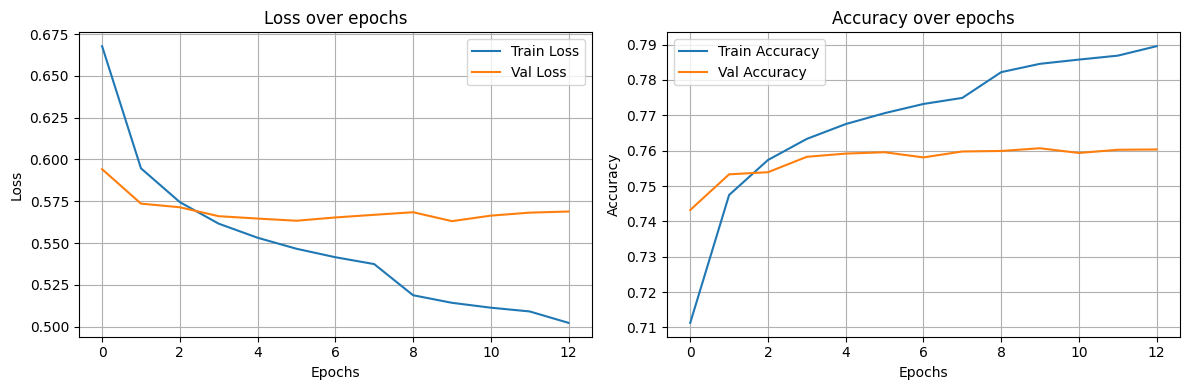

In [110]:
# Ploting the graph

# Plot loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy (if available)
if 'accuracy' in history.history:
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluation

In [111]:
loss, accuracy = model.evaluate(test_padded, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

Test Accuracy: 76.13%
Test Loss: 0.5634


# Classification Report

In [112]:
import numpy as np
from sklearn.metrics import classification_report
# To print a report, we need to convert probabilities back to single class predictions
y_pred_probs = model.predict(test_padded)
y_pred = np.argmax(y_pred_probs, axis=1) # Get the index (class) with the highest probability

# We also need to convert the one-hot y_test back to single numbers
y_test_labels = np.argmax(y_test, axis=1)

print("\n--- Classification Report (Deep Learning) ---")
print(classification_report(y_test_labels, y_pred, target_names=encoder.classes_))

17868/17868 [==============================] - 243s 14ms/step

--- Classification Report (Deep Learning) ---
              precision    recall  f1-score   support

    negative       0.77      0.79      0.78    239513
     neutral       0.63      0.62      0.62     83142
    positive       0.80      0.78      0.79    249108

    accuracy                           0.76    571763
   macro avg       0.73      0.73      0.73    571763
weighted avg       0.76      0.76      0.76    571763



In [113]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_labels, y_pred)
print(cm)

[[189104  15160  35249]
 [ 18116  51151  13875]
 [ 38725  15379 195004]]


# Eporting Model

In [114]:
!pip install joblib
import joblib

# --- 1. Save the Keras Model ---
# This saves the architecture, weights, and optimizer
print("Saving Keras model...")
model.save('modelB.keras') 
print("Model saved to 'modelB.keras'")

# --- 2. Save the Tokenizer ---
# We use joblib (or pickle) for standard Python objects
print("Saving Tokenizer...")
joblib.dump(tokenizer, 'tokenizerB.joblib')
print("Tokenizer saved to 'tokenizerB.joblib'")

# --- 3. Save the Label Encoder ---
print("Saving LabelEncoder...")
joblib.dump(encoder, 'encoderB.joblib')
print("LabelEncoder saved to 'encoderB.joblib'")

Saving Keras model...
Model saved to 'modelB.keras'
Saving Tokenizer...
Tokenizer saved to 'tokenizerB.joblib'
Saving LabelEncoder...
LabelEncoder saved to 'encoderB.joblib'


# Evaluating on best model

In [116]:
best_model = keras.models.load_model('best_sentiment_model.keras')

In [117]:
loss, accuracy = best_model.evaluate(test_padded, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

Test Accuracy: 76.13%
Test Loss: 0.5634
